# Data Exploration
Examine raw data: MOT accident CSVs, OSM GeoPackages, and iTIC probe data.

In [12]:
import pandas as pd
import geopandas as gpd
import tarfile
import matplotlib.pyplot as plt

## 1. MOT Accident Data

In [13]:
accident = pd.read_csv('../data/raw/MOT_accident_data/accidents_2019.csv')
print(accident.shape)
accident.head()

(19373, 39)


,_id,ปีที่เกิดเหตุ,วันที่เกิดเหตุ,เวลา,วันที่รายงาน,เวลาที่รายงาน,ACC_CODE,หน่วยงาน,สายทางหน่วยงาน,รหัสสายทาง,...,รถบรรทุก6ล้อ,รถบรรทุกไม่เกิน10ล้อ,รถบรรทุกมากกว่า10ล้อ,รถอีแต๋น,รถอื่นๆ,คนเดินเท้า,ผู้เสียชีวิต,ผู้บาดเจ็บสาหัส,ผู้บาดเจ็บเล็กน้อย,รวมจำนวนผู้บาดเจ็บ
0,1,2019,2019-01-01T00:00:00,0:00,2019-01-02T00:00:00,6:11,571905,กรมทางหลวงชนบท,ทางหลวงชนบท,ลบ.2029,...,0,0,0,0,0,0,0,0,2,2
1,2,2019,2019-01-01T00:00:00,0:03,2020-02-20T00:00:00,13:48,3790870,กรมทางหลวง,ทางหลวง,24,...,0,0,0,0,0,0,0,0,2,2
2,3,2019,2019-01-01T00:00:00,0:05,2019-01-01T00:00:00,10:35,599075,กรมทางหลวง,ทางหลวง,3168,...,0,0,0,0,0,0,1,0,0,0
3,4,2019,2019-01-01T00:00:00,0:20,2019-01-02T00:00:00,5:12,571924,กรมทางหลวงชนบท,ทางหลวงชนบท,ชม.4016,...,0,0,0,0,0,0,0,0,1,1
4,5,2019,2019-01-01T00:00:00,0:25,2019-01-04T00:00:00,9:42,599523,กรมทางหลวง,ทางหลวง,225,...,0,0,0,0,0,0,0,0,0,0


In [14]:
accident.dtypes

_id                       int64
ปีที่เกิดเหตุ             int64
วันที่เกิดเหตุ           object
เวลา                     object
วันที่รายงาน             object
เวลาที่รายงาน            object
ACC_CODE                  int64
หน่วยงาน                 object
สายทางหน่วยงาน           object
รหัสสายทาง               object
สายทาง                   object
KM                      float64
จังหวัด                  object
รถคันที่1                object
บริเวณที่เกิดเหตุ        object
มูลเหตุสันนิษฐาน         object
ลักษณะการเกิดเหตุ        object
สภาพอากาศ                object
LATITUDE                float64
LONGITUDE               float64
รถที่เกิดเหตุ             int64
รถและคนที่เกิดเหตุ        int64
รถจักรยานยนต์             int64
รถสามล้อเครื่อง           int64
รถยนต์นั่งส่วนบุคคล       int64
รถตู้                     int64
รถปิคอัพโดยสาร            int64
รถโดยสารมากกว่า4ล้อ       int64
รถปิคอัพบรรทุก4ล้อ        int64
รถบรรทุก6ล้อ              int64
รถบรรทุกไม่เกิน10ล้อ      int64
รถบรรทุก

In [15]:
accident.isnull().sum()

_id                        0
ปีที่เกิดเหตุ              0
วันที่เกิดเหตุ             0
เวลา                       0
วันที่รายงาน               0
เวลาที่รายงาน              0
ACC_CODE                   0
หน่วยงาน                   0
สายทางหน่วยงาน             0
รหัสสายทาง                 0
สายทาง                    42
KM                       113
จังหวัด                   11
รถคันที่1                166
บริเวณที่เกิดเหตุ        211
มูลเหตุสันนิษฐาน         220
ลักษณะการเกิดเหตุ       1531
สภาพอากาศ                  0
LATITUDE                  71
LONGITUDE                 71
รถที่เกิดเหตุ              0
รถและคนที่เกิดเหตุ         0
รถจักรยานยนต์              0
รถสามล้อเครื่อง            0
รถยนต์นั่งส่วนบุคคล        0
รถตู้                      0
รถปิคอัพโดยสาร             0
รถโดยสารมากกว่า4ล้อ        0
รถปิคอัพบรรทุก4ล้อ         0
รถบรรทุก6ล้อ               0
รถบรรทุกไม่เกิน10ล้อ       0
รถบรรทุกมากกว่า10ล้อ       0
รถอีแต๋น                   0
รถอื่นๆ                    0
คนเดินเท้า    

## 2. OSM Vector Data

In [16]:
roads = gpd.read_file('../data/raw/osm/osm_roads.gpkg')
print(roads.shape)
print(roads.crs)
roads.head()

(251567, 10)
EPSG:4326


,element,id,amenity,building,highway,landuse,name,oneway,lanes,geometry
0,node,61703358,nan,nan,traffic_signals,nan,nan,nan,nan,POINT (100.60235 13.66226)
1,node,61703359,nan,nan,traffic_signals,nan,nan,nan,nan,POINT (100.60092 13.65877)
2,node,61705868,nan,nan,traffic_signals,nan,nan,nan,nan,POINT (100.64595 13.67782)
3,node,61705883,nan,nan,traffic_signals,nan,nan,nan,nan,POINT (100.64121 13.7356)
4,node,61709729,nan,nan,traffic_signals,nan,nan,nan,nan,POINT (100.56134 13.73645)


In [17]:
buildings = gpd.read_file('../data/raw/osm/osm_buildings.gpkg')
print(buildings.shape)
buildings.head()

(188077, 9)


,element,id,amenity,building,highway,landuse,shop,name,geometry
0,node,280179417,nan,yes,nan,nan,nan,nan,POINT (100.55972 13.72985)
1,node,891268834,nan,apartments,nan,nan,nan,บ้านชูวิเชียร,POINT (100.56967 13.83939)
2,node,891270814,nan,university,nan,nan,nan,คณะสังคมศาสตร์,POINT (100.57014 13.84995)
3,node,891270838,nan,university,nan,nan,nan,คณะศึกษาศาสตร์ มหาวิทยาลัยเกษตรศาสตร์,POINT (100.56994 13.85072)
4,node,891270839,nan,university,nan,nan,nan,คณะอุตสาหกรรมเกษตร,POINT (100.57118 13.85152)


In [18]:
landuse = gpd.read_file('../data/raw/osm/osm_landuse.gpkg')
print(landuse.shape)
landuse.head()

(13720, 10)


,element,id,amenity,building,highway,landuse,shop,name,oneway,geometry
0,node,893939043,nan,nan,nan,residential,nan,เดอะรอยัลวิภาวดี,nan,POINT (100.56245 13.84345)
1,node,4715447090,nan,nan,nan,residential,nan,S.N.P Apartment,nan,POINT (100.63658 13.76898)
2,node,4827413906,nan,nan,nan,military,nan,สนามยิงปืน หน่วยบัญชาการรักษาดินแดน,nan,POINT (100.49555 13.74574)
3,node,5630097640,nan,nan,nan,military,nan,nan,nan,POINT (100.57684 13.8525)
4,node,6732929585,nan,nan,nan,residential,nan,TYST Residence,nan,POINT (100.57242 13.77632)


In [19]:
poi = gpd.read_file('../data/raw/osm/osm_poi.gpkg')
print(poi.shape)
poi.head()

(9489, 9)


,element,id,amenity,building,highway,landuse,shop,name,geometry
0,node,268242835,restaurant,nan,nan,nan,nan,Manna,POINT (100.53455 13.7477)
1,node,280389453,school,nan,nan,nan,nan,Australian International School,POINT (100.56373 13.72817)
2,node,291433291,nan,nan,nan,nan,convenience,7-Eleven,POINT (100.4877 13.6512)
3,node,291433318,nan,nan,nan,nan,convenience,7-Eleven,POINT (100.48824 13.65067)
4,node,292743083,fuel,nan,nan,nan,nan,Shell,POINT (100.56736 13.71857)


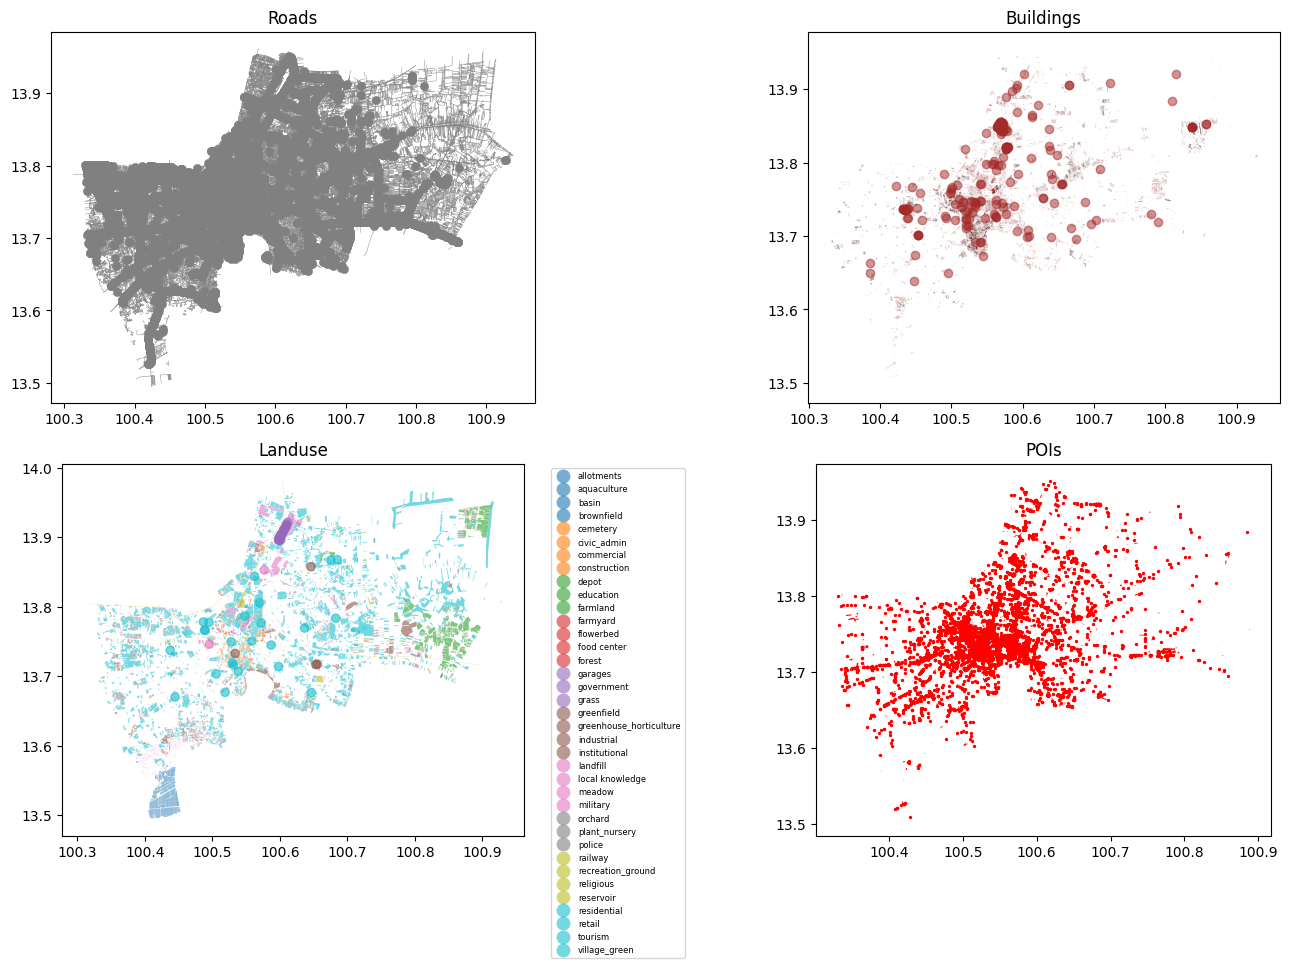

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

roads.plot(ax=axes[0, 0], linewidth=0.3, color='gray')
axes[0, 0].set_title('Roads')

buildings.plot(ax=axes[0, 1], color='brown', alpha=0.5)
axes[0, 1].set_title('Buildings')

landuse.plot(ax=axes[1, 0], column='landuse', legend=True,
             legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1), 'fontsize': 6},
             alpha=0.6)
axes[1, 0].set_title('Landuse')

poi.plot(ax=axes[1, 1], markersize=2, color='red')
axes[1, 1].set_title('POIs')

plt.tight_layout()
plt.show()

## 3. iTIC Probe Data

In [ ]:
PROBE_COLS = ['vehicle_id', 'gps_valid', 'lat', 'lon', 'timestamp', 'speed', 'heading', 'for_hire_light', 'engine_acc']

with tarfile.open('../data/raw/iTIC_probe_data/PROBE-201901.tar.bz2', 'r:bz2') as tar:
    print('Files inside:', tar.getnames()[:5])
    first = tar.getmembers()[0]
    f = tar.extractfile(first)
    probe = pd.read_csv(f, header=None, names=PROBE_COLS, nrows=10000)

print(probe.shape)
probe.head()

In [ ]:
probe.dtypes

In [ ]:
probe['speed'].describe()

In [ ]:
BANGKOK_BBOX = dict(lat_min=13.4, lat_max=14.0, lon_min=100.3, lon_max=100.9)

probe_bkk = probe[
    (probe['gps_valid'] == 1) &
    (probe['speed'] > 0) &
    (probe['lat'].between(BANGKOK_BBOX['lat_min'], BANGKOK_BBOX['lat_max'])) &
    (probe['lon'].between(BANGKOK_BBOX['lon_min'], BANGKOK_BBOX['lon_max']))
]

print(f'Bangkok points: {len(probe_bkk)} / {len(probe)}')
probe_bkk.head()